## **Agent Tool Selection Strategies — Part 1 of 5**
#### **Understanding Exploration vs. Exploitation in Production AI Systems**

> **Author:** Isaac Cobena Appiah</br> 
> **Date:** January, 2026</br> 
> **Type:** Medium/Substack/Website (talkcodetome.com) Tutorial
> 
*Why tool selection is the hardest decision an agent makes — set up as a multi-armed bandit, with a synthetic environment and a hard look at signal vs. noise.*

> **Series:** Part 1 · Part 2 · Part 3 · Part 4 · Part 5  —  *you are reading Part 1.*
### **An Introduction to How AI Agents Choose Their Tools**

AI agents can now search the web, query databases, call APIs, write code, schedule meetings, and act on software on our behalf. But an agent is only as effective as the decisions it makes about **which tool to use**.

Imagine an agent with access to ten different tools: a database lookup, web search, calculator, knowledge base, order tracker, refund processor, scheduling API, analytics engine, email service, and human escalation. Every time a new request arrives, the agent faces the same question:

> **Which tool should I choose?**

At first glance, the answer seems obvious: use the tool that worked last time. Unfortunately, that is exactly how many agents get stuck.

Suppose a customer asks, *"Where is my order?"* The first time, the agent answers correctly using a web search. The next customer asks something similar, so it reaches for web search again. Then again. Eventually it routes almost every request through the same tool — even when a direct database lookup would answer in milliseconds, or the knowledge base would return a more accurate response.

The problem is not that the agent *cannot* use the other tools; it simply has no reason to believe they would perform any better.

This behaviour is known as **greedy exploitation**, and it sits at the heart of one of the most important problems in reinforcement learning and agentic AI: the **exploration–exploitation trade-off**. Should an agent keep using the tool it already trusts, or occasionally try another that might perform even better?

Every autonomous system faces this dilemma.

- **Customer support agent** : Use the familiar FAQ search or try the database?
- **Coding assistant**       : Search previous code or explore the documentation?                  
- **Research agent**         : Query trusted sources or investigate new ones?                      
- **Browser agent**          : Follow the known navigation path or test another route?             
- **Medical assistant**      : Use the standard diagnostic workflow or consult a specialist model? 
- **Trading system**         : Execute a proven strategy or evaluate a new one?                    

Choose too little exploration, and the agent may never discover better tools. Explore too aggressively, and it wastes time, money, and user trust. Designing an agent that balances these competing goals is one of the central challenges in modern AI systems.

In this tutorial, we'll build that intuition from first principles. Rather than treating the exploration–exploitation trade-off as abstract theory, we'll create a small simulation environment in Python where several tools compete over thousands of interactions. We'll implement increasingly sophisticated decision strategies, visualise how they learn, and see why some approaches consistently outperform others.

If you're comfortable with basic Python, NumPy, and a little object-oriented programming, you have everything you need. We'll develop the underlying mathematics, algorithms, and visualizations step by step from the ground up, and by the end you'll understand not only **how AI agents choose their tools**, but **why those decisions determine whether an agent succeeds or fails in production**.

#### **Why build a simulation at all?**

One of the most valuable habits in AI engineering is learning to build **controlled experiments**. Production agents operate in environments that are noisy, expensive to evaluate, difficult to reproduce, and often constrained by privacy or safety requirements. Before deploying a new decision strategy, we should be able to simulate it, observe how it behaves under different conditions, and identify where it is likely to fail.

That is exactly what we'll do here. Instead of experimenting on a live customer-support agent, we'll build a synthetic environment where the available tools and their success rates are entirely under our control. Unlike production systems — where the optimal action is unknown — we know the underlying **ground truth** inside our simulation. This lets us measure precisely how quickly each strategy discovers the best tool, and how much reward it sacrifices while learning.

The distinction we'll return to throughout is fundamental:

* **A guessing agent** selects tools using fixed rules, intuition, or simple heuristics.
* **A learning agent** continually updates its beliefs from experience, improving its decisions over time.

We'll implement both approaches from scratch, compare their behavior under identical conditions, and build an intuition for why successful AI agents must balance **exploration** with **exploitation**.

#### **What We Will Build (Full Outline)**

1. [Environment Setup](#setup)
2. [The Multi-Armed Bandit — The Foundation](#bandit)
3. [Build the Synthetic Agent Environment](#environment)
4. [Signal vs. Noise in Tool Environments](#signal-noise)
5. [Greedy Agent — High Bias, Low Variance](#greedy)
6. [Random Agent — Low Bias, High Variance](#random)
7. [Epsilon-Greedy — Finding the Sweet Spot](#epsilon)
8. [Upper Confidence Bound (UCB) Agent](#ucb)
9. [The 9-Trial Comparison Grid](#nine-trial)
10. [Learning Curves — Visual Trade-off Analysis](#learning)
11. [The Exploration-Exploitation Decomposition](#decomposition)
12. [Epsilon Sensitivity Analysis](#epsilon-analysis)
13. [Advanced Environments — Cost, Drift, Positional Bias](#advanced-env)
14. [Production AI Engineering Perspective](#production)
15. [Advanced Architectures](#advanced-arch)
16. [Engineering Best Practices](#checklist)
17. [Putting It All Together](#summary)

With that foundation in place, we can set up the simulation environment and define the parameters every experiment will share.
### **1. Environment Setup**

Before building any agents, we need a reproducible simulation environment. Unlike production systems — where every experiment may involve live users, external APIs, or shifting data — our simulation should behave identically every time it runs. This lets us compare decision strategies fairly and attribute performance differences to the algorithms themselves rather than to random chance.

To achieve this, we first import the libraries that will support the whole project, establish a few global configuration variables, and fix a random seed for reproducibility. Every experiment in the tutorial uses these same settings so results stay directly comparable.

**Why this step matters**

A well-configured experimental environment provides several benefits:

* **Reproducibility** — every simulation can be recreated exactly.
* **Fair comparison** — competing strategies run under identical conditions.
* **Consistent visualisations** — every plot shares the same styling and colour conventions.
* **Maintainability** — global parameters live in one place and can be changed without touching the rest of the notebook.

Without these foundations, two agents may appear to perform differently simply because they encountered different random events rather than because one strategy is genuinely better.

### **What we'll configure**

At the beginning of the project, we'll define:

* Python library imports
* Global random seed
* Simulation parameters
* Plotting defaults
* Color palette for comparing algorithms
* and the task–tool definitions used throughout the notebook.

Keeping these settings centralized makes the project easier to understand, reproduce, and extend.

#### **Engineering Best Practices**

As simulations grow, a few habits pay off: use descriptive names, avoid hard-coded "magic numbers", isolate reusable logic into functions or classes, keep the environment definition separate from the agent implementation, and keep experiments deterministic wherever possible.

#### **Production Perspective**

Although our environment is synthetic, the workflow mirrors how reinforcement-learning systems are often developed in practice. Rather than experimenting directly in production, engineers validate new algorithms in controlled simulators where performance can be measured safely, repeatedly, and cheaply. Once a strategy performs well in simulation, it can be evaluated in progressively more realistic environments before deployment.

#### **Importing the Required Libraries**

This project relies on a small scientific Python stack:

* **NumPy**  : for numerical computation and random sampling 
* **Matplotlib** : for static visualizations (`gridspec` and `patches` handle layout and annotations)
* **Seaborn** : for plot styling and statistical aesthetics
* **collections** (`defaultdict`, `Counter`) — lightweight bookkeeping of tasks and outcomes
* **warnings** — kept quiet so the notebook output stays clean

Together these provide everything we need to build, evaluate, and visualise multi-armed bandit algorithms.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict, Counter
import warnings

warnings.filterwarnings("ignore")

#### **Ensuring Reproducible Experiments**

Many components of this project are intentionally stochastic.

Examples include:

* randomly generated tasks,
* stochastic tool rewards,
* exploration decisions,
* randomized agent behaviour.

Without fixing the random seed, every notebook execution would produce slightly different results, making it difficult to compare algorithms or verify conclusions.

To ensure every algorithm is evaluated under identical conditions, we define a single global seed.

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

Next, we establish the global parameters that control every experiment in the tutorial.
#### **Defining the Simulation Parameters**

Rather than scattering configuration values throughout the notebook, we define them once at the beginning.

Examples include:

* number of available tools
* number of simulated tasks
* number of interaction rounds
* exploration rates
* confidence parameters
* plotting colors

In [3]:
N_TASKS        = 200     # Tasks per simulation run
N_TRIALS       = 9       # Repeated trials per strategy (for 3×3 grid)
N_AVG_TRIALS   = 50      # Trials for averaged learning curves
N_STRATEGIES   = 4       # Greedy, Random, Epsilon-Greedy, UCB

Keeping these values in one place makes the simulation easier to modify and guarantees consistency across every experiment.
#### **Defining the Agent's Available Tools**
Our agent has access to five different tools.

In [4]:
TOOLS = {
    'search_faq':       'Search FAQ database (fast, focused)',
    'query_database':   'Retrieve customer records (accurate, specific)',
    'web_search':       'Search external web (broad, noisy)',
    'calculator':       'Perform calculations (deterministic)',
    'email_api':        'Escalate to human support',
}
TOOL_NAMES = list(TOOLS.keys())
N_TOOLS    = len(TOOL_NAMES)

These tools intentionally resemble those available to real customer-support agents. Each tool performs well for certain tasks but poorly for others, forcing the agent to learn which one to select.
#### **Defining the Task Environment**

Next, we define the different requests the agent may receive.

In [5]:
TASK_TYPES = {
    'order_status':    {'optimal_tool': 'query_database', 'base_success': 0.95},
    'password_reset':  {'optimal_tool': 'search_faq',     'base_success': 0.90},
    'calculation':     {'optimal_tool': 'calculator',     'base_success': 1.00},
    'return_policy':   {'optimal_tool': 'web_search',     'base_success': 0.75},
    'complex_issue':   {'optimal_tool': 'email_api',      'base_success': 0.82},
}
TASK_NAMES = list(TASK_TYPES.keys())
N_TASKS_T  = len(TASK_NAMES)

Each task has an optimal tool and an associated probability of success. This mapping represents the hidden ground truth of our simulation.

Importantly, **the agent never sees this table**. It must discover these relationships through experience alone.
#### **Establishing Consistent Visual Design**

Since we'll compare several learning strategies throughout the tutorial, we assign each algorithm a consistent color that will be reused across every figure.

In [6]:
PALETTE = {
    'greedy':      '#e74c3c',    # Red    — greedy (high bias)
    'random':      '#9b59b6',    # Purple — random (high variance)
    'epsilon':     '#27ae60',    # Green  — epsilon-greedy (balanced)
    'ucb':         '#2980b9',    # Blue   — UCB (intelligent)
    'optimal':     '#2c3e50',    # Dark   — optimal signal line
    'noise':       '#95a5a6',    # Grey   — noise / background
    'highlight':   '#f39c12',    # Amber  — emphasis
    'background':  '#f8f9fa',    # Light  — panel backgrounds
    'reward':      '#1abc9c',    # Teal   — reward/success signal
}

STRATEGY_COLORS = {
    'Greedy':           PALETTE['greedy'],
    'Random':           PALETTE['random'],
    'Epsilon-Greedy':   PALETTE['epsilon'],
    'UCB':              PALETTE['ucb'],
}

Using the same visual language throughout the project makes the results easier to interpret as the experiments become more complex.
#### **Configuring Plot Defaults**

Finally, we configure Matplotlib once at the beginning so every visualization follows the same style.

In [7]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 110, 'axes.titlesize': 11,
    'axes.labelsize': 10, 'font.size': 9, 'lines.linewidth': 2.2,
})

Then we verify the environment before building our first agent. It's good practice to verify that the simulation environment has been configured correctly.

In [8]:
print(f"Random state  : {RANDOM_STATE}")
print(f"Tasks / run   : {N_TASKS}")
print(f"Trials        : {N_TRIALS} per strategy (grid) | {N_AVG_TRIALS} (learning curves)")
print(f"Tools         : {N_TOOLS} — {TOOL_NAMES}")
print(f"Task types    : {N_TASKS_T} — {TASK_NAMES}")
print()
print("Ground Truth Environment (Hidden from the Agent):")
print(f"{'Task':<20} {'Optimal Tool':<20} {'Base Success'}")
print(" ")
for task, info in TASK_TYPES.items():
    print(f"{task:<20} {info['optimal_tool']:<20} {info['base_success']:.0%}")

Random state  : 42
Tasks / run   : 200
Trials        : 9 per strategy (grid) | 50 (learning curves)
Tools         : 5 — ['search_faq', 'query_database', 'web_search', 'calculator', 'email_api']
Task types    : 5 — ['order_status', 'password_reset', 'calculation', 'return_policy', 'complex_issue']

Ground Truth Environment (Hidden from the Agent):
Task                 Optimal Tool         Base Success
 
order_status         query_database       95%
password_reset       search_faq           90%
calculation          calculator           100%
return_policy        web_search           75%
complex_issue        email_api            82%


### **2. The Multi-Armed Bandit Problem**

Before we build our first agent, we need to understand the mathematical problem it is trying to solve. Although modern AI agents may call APIs, search the web, query databases, or execute code, they are all making the same fundamental decision:

> **Which action should I take next?**

This question is formalized by one of the most influential problems in machine learning and reinforcement learning: the **multi-armed bandit**.

The name comes from an old casino analogy. Imagine standing in front of several slot machines (traditionally called *one-armed bandits*). Each machine has an unknown probability of paying out, and you have a limited number of pulls. Your objective is simple: maximize the total reward you collect.

This immediately raises a fundamental question: should the agent exploit the tool it currently believes is best, or explore alternatives that could yield even greater rewards? 

This is known as the **exploration–exploitation trade-off**, and it lies at the heart of nearly every intelligent decision-making system.

For AI agents, the analogy maps almost perfectly.

| Casino                     | AI Agent                     |
| -------------------------- | ---------------------------- |
| Slot machine               | Tool                         |
| Pull                       | Tool invocation              |
| Payout                     | Reward or successful outcome |
| Unknown payout probability | Unknown tool effectiveness   |
| Player                     | Agent                        |

Every time an agent receives a task, it must decide which tool to invoke. Some tools have worked well before, while others remain uncertain. Choosing only familiar tools may prevent the agent from discovering better alternatives. Exploring too aggressively, however, wastes time, computational resources, and user trust.

Mathematically, the interaction unfolds as follows.

```
At each time step t:

1. The agent selects one of K available tools from {1, ..., K}.
2. The environment returns a reward r_t ~ P(reward | tool=a_t, task=context).
3. The agent updates its estimate of that tool's quality.
4. The process repeats.
```

The objective is to maximize the cumulative reward collected over many interactions while minimizing **regret**—the performance gap between the agent's decisions and those of an ideal strategy that always knew the best tool.

If this trade-off sounds familiar, that's because we've seen it before in supervised learning.

A very simple regression model has high bias: it makes stable predictions but consistently misses complex patterns. An overly flexible model has high variance: it can fit the training data extremely well but often fails to generalize. Effective machine learning lies between these two extremes.

Tool-selection strategies face the same challenge.

| Strategy                     | Behaviour                                                              |
| ---------------------------- | ---------------------------------------------------------------------- |
| Greedy                       | Explores too little and may become trapped in a suboptimal choice      |
| Random                       | Explores constantly but never fully exploits what it learns            |
| Epsilon-Greedy               | Mostly exploits while occasionally exploring                           |
| Upper Confidence Bound (UCB) | Explores uncertain options intelligently based on confidence estimates |

Rather than discussing these ideas only in theory, we'll build each strategy ourselves and watch them compete inside a controlled simulation. Seeing how they learn over time provides a much deeper understanding than equations alone.

With the theory in place, our next step is to visualize the bandit problem before implementing the environment and the agents themselves.
#### **2. Visualizing the Multi-Armed Bandit Problem**
The figure below illustrates the three ideas at the heart of every bandit problem:

* the **true** performance of each tool (which the agent never knows),
* the **noisy observations** the agent actually learns from,
* and the **cost of poor decisions**, measured as cumulative regret.

Understanding these three concepts makes the exploration–exploitation trade-off much more intuitive.

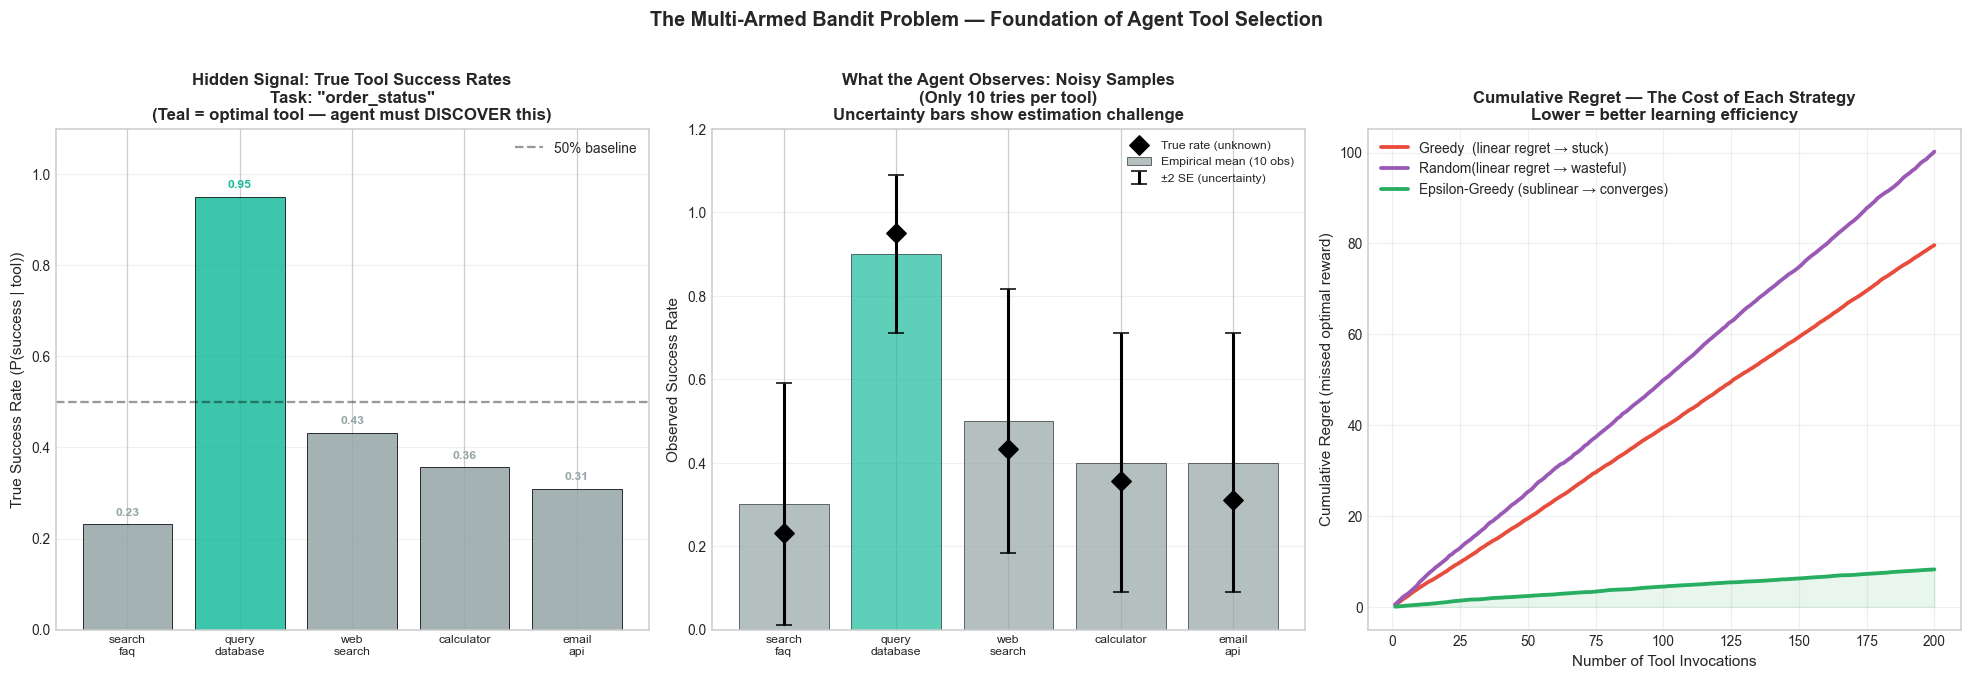

True Tool Success Rates (hidden from agent):
order_status        : optimal=query_database       P(success)=0.95
password_reset      : optimal=search_faq           P(success)=0.90
calculation         : optimal=calculator           P(success)=1.00
return_policy       : optimal=web_search           P(success)=0.75
complex_issue       : optimal=email_api            P(success)=0.82


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Left: True tool success rates (the hidden signal)
ax1 = axes[0]

# Example task used purely for illustration
task_shown = 'order_status'
true_rates = {}
for tool in TOOL_NAMES:
    # Optimal tool gets base_success; others get much lower rates
    if tool == TASK_TYPES[task_shown]['optimal_tool']:
        true_rates[tool] = TASK_TYPES[task_shown]['base_success']
    else:
        true_rates[tool] = np.random.uniform(0.1, 0.45)

bar_colors = [PALETTE['reward'] if t == TASK_TYPES[task_shown]['optimal_tool']
              else PALETTE['noise'] for t in TOOL_NAMES]
bars = ax1.bar(range(N_TOOLS), [true_rates[t] for t in TOOL_NAMES],
               color = bar_colors, edgecolor = 'black', lw = 0.6, alpha = 0.85)
ax1.set_xticks(range(N_TOOLS))
ax1.set_xticklabels([t.replace('_', '\n') for t in TOOL_NAMES], fontsize=8)
ax1.set_ylabel('True Success Rate (P(success | tool))')
ax1.set_title(f'Hidden Signal: True Tool Success Rates\nTask: "{task_shown}"\n'
              f'(Teal = optimal tool — agent must DISCOVER this)',
              fontweight = 'bold')
ax1.set_ylim(0, 1.1)
ax1.axhline(0.5, color = 'black', ls = '--', lw = 1.5, alpha = 0.4, label = '50% baseline')
ax1.legend(fontsize = 9)
ax1.grid(alpha = 0.3, axis = 'y')
for bar, tool in zip(bars, TOOL_NAMES):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{true_rates[tool]:.2f}', ha = 'center', fontsize = 8, fontweight = 'bold',
             color = PALETTE['reward'] if tool == TASK_TYPES[task_shown]['optimal_tool']
             else PALETTE['noise'])

# Middle: What the agent OBSERVES (noisy samples) 
ax2 = axes[1]

# Show 10 noisy observations per tool (what the agent learns from)
n_obs = 10
obs_by_tool = {}
np.random.seed(RANDOM_STATE)
for tool in TOOL_NAMES:
    obs_by_tool[tool] = [1 if np.random.random() < true_rates[tool] else 0
                          for _ in range(n_obs)]

means_obs = {t: np.mean(obs_by_tool[t]) for t in TOOL_NAMES}
stds_obs  = {t: np.std(obs_by_tool[t]) / np.sqrt(n_obs) for t in TOOL_NAMES}

bar_colors2 = [PALETTE['reward'] if t == TASK_TYPES[task_shown]['optimal_tool']
               else PALETTE['noise'] for t in TOOL_NAMES]
ax2.bar(range(N_TOOLS), [means_obs[t] for t in TOOL_NAMES],
        color=bar_colors2, alpha=0.7, edgecolor='black', lw=0.5,
        label=f'Empirical mean ({n_obs} obs)')
ax2.errorbar(range(N_TOOLS), [means_obs[t] for t in TOOL_NAMES],
             yerr = [stds_obs[t]*2 for t in TOOL_NAMES],
             fmt = 'none', color = 'black', capsize = 5, lw = 2, label = '±2 SE (uncertainty)')

# True rates as dots
ax2.scatter(range(N_TOOLS), [true_rates[t] for t in TOOL_NAMES],
            color = 'black', s = 80, zorder = 6, marker = 'D', label = 'True rate (unknown)')
ax2.set_xticks(range(N_TOOLS))
ax2.set_xticklabels([t.replace('_', '\n') for t in TOOL_NAMES], fontsize = 8)
ax2.set_ylabel('Observed Success Rate')
ax2.set_title(f'What the Agent Observes: Noisy Samples\n(Only {n_obs} tries per tool)\n'
              'Uncertainty bars show estimation challenge', fontweight = 'bold')
ax2.set_ylim(0, 1.2)
ax2.legend(fontsize = 8); ax2.grid(alpha = 0.3, axis = 'y')

# Right: Regret accumulation concept 
ax3 = axes[2]
T_steps = np.arange(1, 201)
optimal_rate = max(true_rates.values())

# Simulate regret for three strategies
np.random.seed(RANDOM_STATE)
regret_greedy  = np.cumsum([optimal_rate - 0.55 + np.random.normal(0, 0.05)
                             for _ in T_steps])
regret_random  = np.cumsum([optimal_rate - np.mean(list(true_rates.values()))
                             + np.random.normal(0, 0.08) for _ in T_steps])
regret_epsilon = np.cumsum([max(0, optimal_rate - 0.88 + np.random.normal(0, 0.03))
                              * (1 / (1 + np.log(t+1) * 0.15)) for t in T_steps])
regret_epsilon = np.maximum.accumulate(np.abs(regret_epsilon))
regret_greedy  = np.maximum.accumulate(np.abs(regret_greedy))

ax3.plot(T_steps, regret_greedy, color = PALETTE['greedy'], lw = 2.5, label = 'Greedy  (linear regret → stuck)')
ax3.plot(T_steps, regret_random, color = PALETTE['random'], lw = 2.5, label = 'Random(linear regret → wasteful)')
ax3.plot(T_steps, regret_epsilon, color = PALETTE['epsilon'], lw = 2.5, label = 'Epsilon-Greedy (sublinear → converges)')
ax3.fill_between(T_steps, 0, regret_epsilon, alpha = 0.1, color = PALETTE['epsilon'])
ax3.set_xlabel('Number of Tool Invocations')
ax3.set_ylabel('Cumulative Regret (missed optimal reward)')
ax3.set_title('Cumulative Regret — The Cost of Each Strategy\nLower = better learning efficiency',
               fontweight = 'bold')
ax3.legend(fontsize = 9); ax3.grid(alpha = 0.3)

plt.suptitle('The Multi-Armed Bandit Problem — Foundation of Agent Tool Selection',
             fontsize = 13, fontweight = 'bold', y = 1.02)
plt.tight_layout()
plt.savefig('agent_01_bandit_foundation.png', dpi = 120, bbox_inches = 'tight')
plt.show()

print("True Tool Success Rates (hidden from agent):")
for task, info in TASK_TYPES.items():
    print(f"{task:<20}: optimal={info['optimal_tool']:<20} P(success)={info['base_success']:.2f}")

**What this figure tells us:**

**1. The hidden signal**

The left panel represents reality. Each tool has a true probability of success for the current task, but the agent never gets to observe these probabilities directly. Its objective is to discover the best tool through experience rather than prior knowledge.

**2. Learning from noisy observations**

The middle panel shows the information available to the agent. After only a handful of interactions, the estimated success rates can differ noticeably from the true values because every observation contains randomness. Early in learning, the agent must therefore make decisions under uncertainty.

**3. The cost of learning**

The right panel introduces **cumulative regret**—the reward lost by not selecting the optimal tool at every opportunity. Different strategies accumulate regret at different rates. A purely greedy strategy can become trapped using a suboptimal tool, while a purely random strategy wastes interactions exploring indefinitely. Balanced strategies, such as ε-greedy, reduce regret over time as they learn which tool performs best.

> With the intuition in place, we are ready to build the environment itself. Instead of relying on an existing reinforcement learning framework, we'll create our own simulation from scratch so that every component from tasks and tools to rewards and learning — is completely transparent.
#### **3. Building the Synthetic Agent Environment**

Theory alone is not enough. Before we can compare different tool-selection strategies, we need an environment in which they can learn.

Rather than relying on logs from a production system, we will build a synthetic agent environment where the optimal tool for every task is known in advance. This gives us something that real-world systems rarely provide: ground truth. We know which tool should be chosen for every task, while the agent must discover that mapping through experience.

The agent never sees this underlying structure directly. It only observes whether a selected tool succeeds or fails and must gradually learn which tools perform best for different types of tasks. This uncertainty is what makes the problem interesting—and what makes exploration necessary.

In [10]:
class AgentEnvironment:
    """
    Synthetic environment for studying AI agent tool selection.
    
    The environment is responsible for three things:
    
    1. Generating incoming user tasks.
    2. Evaluating the tool selected by the agent.
    3. Returning a reward that indicates whether the tool succeeded.
    
    The agent never observes the true success probabilities or the
    optimal tool for any task. It must discover those relationships
    through trial and error.
    
    This closely resembles production agent systems, where only the
    outcome of an action—not the underlying ground truth—is visible.
    """
    def __init__(self, noise_level=0.15, seed=None):
        """
        Parameters
        ----------
        noise_level : float
            Controls how often even the optimal tool fails (environment stochasticity).
            noise_level=0   → deterministic environment (only optimal tool succeeds)
            noise_level=0.3 → chaotic environment (tools fail randomly)
        seed : int
            Random seed for reproducibility.
        """
        self.noise_level = noise_level
        self.rng = np.random.default_rng(seed)
        self.task_history = []
        self.reward_history = []
        self.step_count = 0

    def generate_task(self):
        """
        Sample the next incoming task.
        
        Each task represents a user request that the agent must solve
        by selecting one of the available tools.
        """
        task_type = self.rng.choice(TASK_NAMES)
        self.step_count += 1
        return task_type

    def execute_tool(self, task_type, tool_name):
        """
        Execute the selected tool for a given task.
        
        The environment compares the chosen tool with the hidden
        optimal tool for that task and generates a stochastic reward.
        
        Optimal tools succeed most of the time, although random noise
        allows occasional failures.
        
        Non-optimal tools usually fail but may occasionally succeed by
        chance.
        
        Returns
        -------
        reward : int
            1 if the tool succeeds, otherwise 0.
        """
        optimal    = TASK_TYPES[task_type]['optimal_tool']
        base_rate  = TASK_TYPES[task_type]['base_success']
        noise      = self.rng.uniform(0, self.noise_level)

        if tool_name == optimal:
            success_prob = base_rate - noise       # HIGH probability
        else:
            success_prob = noise * 0.4             # LOW probability (mostly fail)

        reward = 1 if self.rng.random() < success_prob else 0
        self.task_history.append(task_type)
        self.reward_history.append(reward)
        return reward

    def reset(self):
        """
        Reset the environment before starting a new simulation.
        
        This clears the interaction history while leaving the underlying
        task-to-tool relationships unchanged.
        """
        self.task_history = []
        self.reward_history = []
        self.step_count = 0

    def get_oracle_rate(self):
        """
        Return the expected success rate of an ideal agent.
        
        The oracle always selects the optimal tool for every task and
        therefore represents the upper performance limit.
        """
        return np.mean([TASK_TYPES[t]['base_success'] for t in TASK_NAMES])


# Test the environment
env_test = AgentEnvironment(noise_level=0.15, seed=RANDOM_STATE)

print("Environment Test:")
print(f"Oracle (optimal) rate: {env_test.get_oracle_rate():.3f}")
print()
print("Simulating 50 tasks with optimal tool selection:")
rewards = []
for _ in range(50):
    task = env_test.generate_task()
    optimal = TASK_TYPES[task]['optimal_tool']
    r = env_test.execute_tool(task, optimal)
    rewards.append(r)
print(f"Observed success rate (optimal): {np.mean(rewards):.3f}")
print()
print("Simulating 50 tasks with worst tool (web_search for everything):")
env_test.reset()
rewards_worst = []
for _ in range(50):
    task = env_test.generate_task()
    r = env_test.execute_tool(task, 'web_search')
    rewards_worst.append(r)
print(f"Observed success rate (web_search only): {np.mean(rewards_worst):.3f}")
print()
print("Gap between optimal and naive strategy: "
      f"{np.mean(rewards) - np.mean(rewards_worst):.3f} — this is what good tool selection recovers")

Environment Test:
Oracle (optimal) rate: 0.884

Simulating 50 tasks with optimal tool selection:
Observed success rate (optimal): 0.840

Simulating 50 tasks with worst tool (web_search for everything):
Observed success rate (web_search only): 0.140

Gap between optimal and naive strategy: 0.700 — this is what good tool selection recovers


Before training any agent, it is good practice to verify that the simulation behaves as intended.

In the small experiment above, we compare two extreme strategies:

* **Oracle strategy:** always chooses the optimal tool for each task.
* **Naive strategy:** always calls the same tool, regardless of the task.

The large performance gap confirms that the environment contains a meaningful learning problem. There is enough signal for a good agent to discover, but enough randomness to prevent perfect performance from a small number of observations.

**What this tells us:**

The synthetic environment behaves exactly as intended. An agent that always selects the correct tool achieves a much higher success rate than one that repeatedly uses the same tool for every task. The gap between these two strategies defines the learning opportunity available to our agents. The challenge is no longer building the environment—it is designing an algorithm that can close this gap through experience.

#### **4. Signal vs. Noise in Agent Tool Selection**

Now that our environment is working, we can examine the central challenge every learning agent faces.

Although every task has an optimal tool, the outcome of calling that tool is not perfectly predictable. Sometimes the best tool fails because of random circumstances. Occasionally, an inferior tool succeeds simply by luck.

The agent never knows whether a successful outcome reflects genuine tool quality or random chance. Its job is to interact with the environment repeatedly until the underlying pattern begins to emerge.

This distinction lies at the heart of sequential decision-making.

* **Signal** refers to the true relationship between tasks and their optimal tools.
* **Noise** represents the randomness that obscures that relationship, such as API failures, ambiguous requests, temporary service outages, or other stochastic events.

The challenge is not simply collecting rewards—it is learning to distinguish reliable patterns from random fluctuations.

An agent that reacts too strongly to a few lucky outcomes may continue using poor tools long after better alternatives exist. Conversely, an agent that dismisses early failures may abandon the optimal tool before gathering enough evidence to recognize its value.

Every tool-selection strategy we study in this tutorial differs in one important respect:

> **How effectively can it separate signal from noise while learning from experience?**

The visualization illustrates this challenge: how signal and noise appear inside the environment. Seeing the hidden structure makes it much easier to understand why some strategies learn quickly while others struggle.

#### **Checking the Task Distribution:**

Before studying how agents learn, let's verify that our environment generates a healthy mix of task types. If one task dominates the simulation, the learning problem becomes artificially easy because the agent spends most of its time solving the same problem.

The following figure shows the frequency of each task generated by the environment.

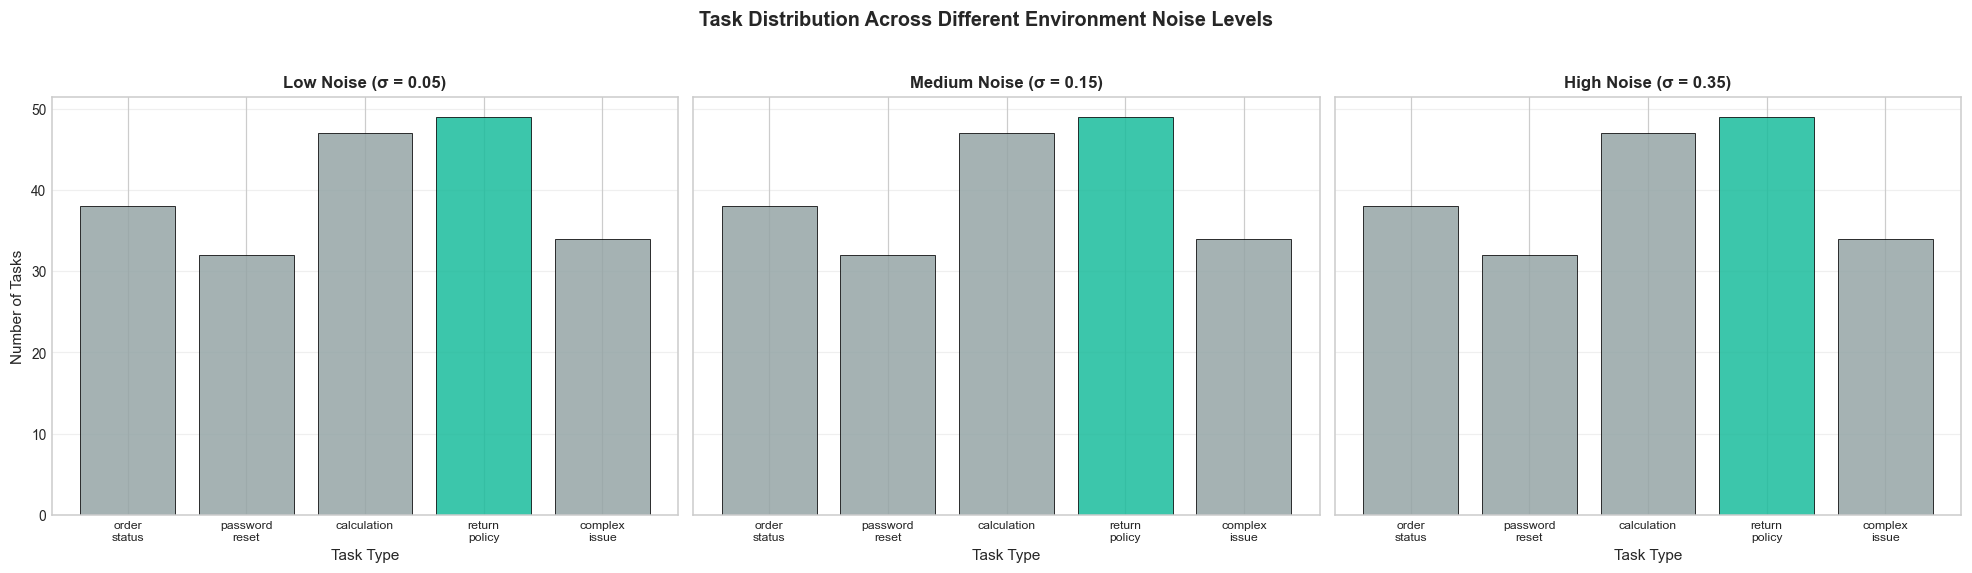

In [11]:
# Task Distribution Under Different Noise Levels
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

noise_levels = [0.05, 0.15, 0.35]
noise_labels = [
    'Low Noise (σ = 0.05)',
    'Medium Noise (σ = 0.15)',
    'High Noise (σ = 0.35)'
]

for ax, noise, label in zip(axes, noise_levels, noise_labels):

    # Create environment
    env = AgentEnvironment(
        noise_level=noise,
        seed=RANDOM_STATE
    )

    # Generate sample tasks
    task_counts = Counter()

    for _ in range(200):
        task = env.generate_task()
        task_counts[task] += 1

    # Highlight the most frequent task
    max_count = max(task_counts.values())

    colors = [
        PALETTE['reward'] if task_counts[task] == max_count
        else PALETTE['noise']
        for task in TASK_NAMES
    ]

    ax.bar(
        range(N_TASKS_T),
        [task_counts[task] for task in TASK_NAMES],
        color=colors,
        edgecolor='black',
        linewidth=0.6,
        alpha=0.85
    )

    ax.set_xticks(range(N_TASKS_T))
    ax.set_xticklabels(
        [task.replace('_', '\n') for task in TASK_NAMES],
        fontsize=8
    )

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel("Task Type")
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel("Number of Tasks")

plt.suptitle(
    "Task Distribution Across Different Environment Noise Levels",
    fontsize=13,
    fontweight='bold',
    y=1.03
)

plt.tight_layout()
plt.show()

**What this tells us:**

The task types appear throughout the simulation with roughly similar frequency. This ensures that every tool receives opportunities to prove its usefulness and prevents the learning process from being dominated by a single task.

#### **How Noise Changes What the Agent Sees:**

Although every task has an optimal tool, the agent never observes the true success probabilities directly. Instead, it sees only noisy outcomes from repeated interactions.

To illustrate this, we gradually increase the amount of environmental noise while measuring the observed success rates of each tool.

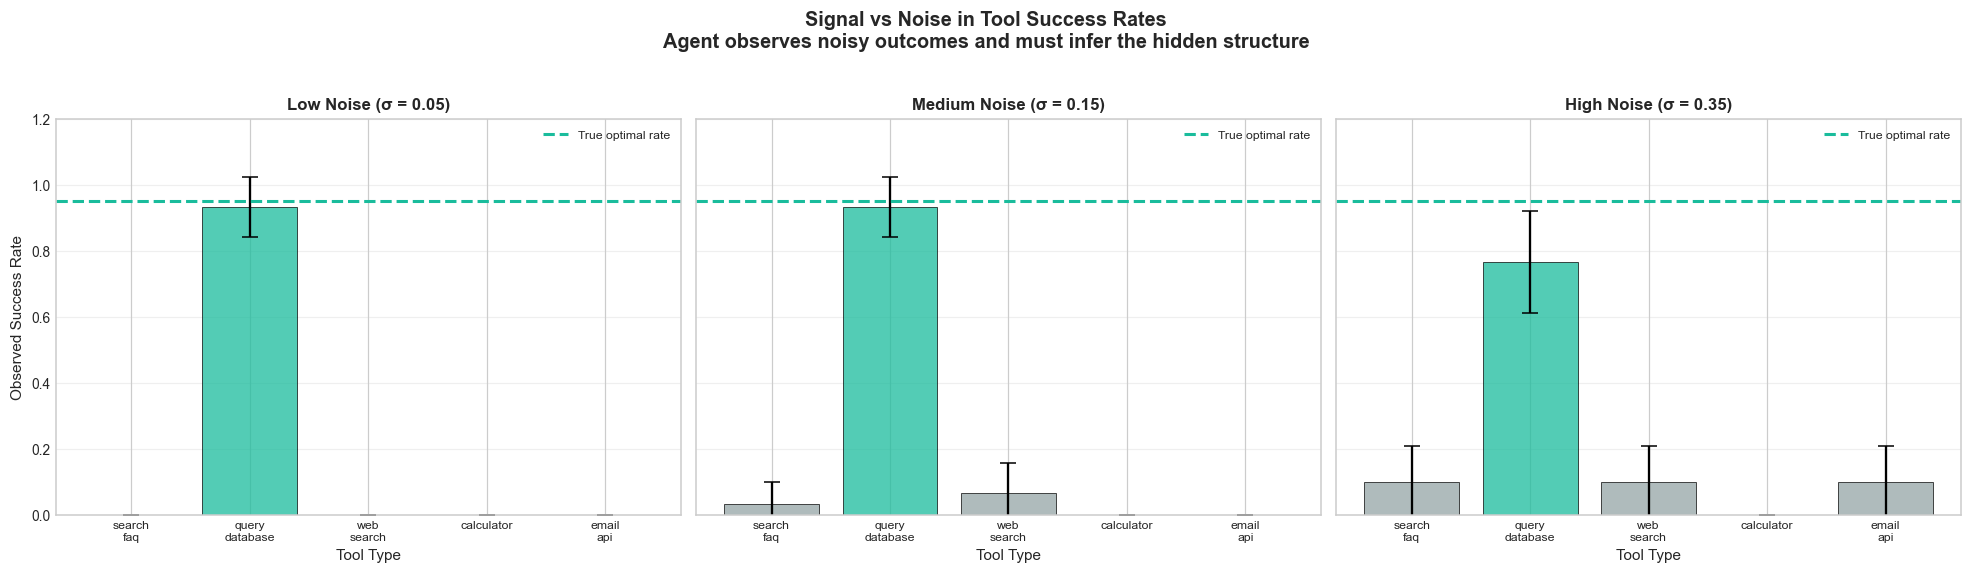

In [12]:
# Tool Success Rates Under Different Noise Levels
# How noise obscures the optimal tool signal
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

noise_levels = [0.05, 0.15, 0.35]
noise_labels = [
    'Low Noise (σ = 0.05)',
    'Medium Noise (σ = 0.15)',
    'High Noise (σ = 0.35)'
]

task_shown = 'order_status'
optimal_tool = TASK_TYPES[task_shown]['optimal_tool']
base_rate = TASK_TYPES[task_shown]['base_success']

n_probe = 30

for ax, noise, label in zip(axes, noise_levels, noise_labels):

    env = AgentEnvironment(
        noise_level=noise,
        seed=RANDOM_STATE
    )

    obs_means = {}
    obs_sems = {}

    # Estimate success rate for each tool
    for tool in TOOL_NAMES:

        results = [
            env.execute_tool(task_shown, tool)
            for _ in range(n_probe)
        ]

        obs_means[tool] = np.mean(results)
        obs_sems[tool] = np.std(results) / np.sqrt(n_probe)

    # Colors: highlight optimal tool
    colors = [
        PALETTE['reward'] if tool == optimal_tool
        else PALETTE['noise']
        for tool in TOOL_NAMES
    ]

    # Bar plot
    ax.bar(
        range(N_TOOLS),
        [obs_means[t] for t in TOOL_NAMES],
        color=colors,
        alpha=0.75,
        edgecolor='black',
        linewidth=0.6
    )

    # Error bars
    ax.errorbar(
        range(N_TOOLS),
        [obs_means[t] for t in TOOL_NAMES],
        yerr=[obs_sems[t] * 2 for t in TOOL_NAMES],
        fmt='none',
        color='black',
        capsize=5,
        lw=1.5
    )

    # True optimal rate reference line
    ax.axhline(
        base_rate,
        color=PALETTE['reward'],
        linestyle='--',
        linewidth=2,
        label='True optimal rate'
    )

    ax.set_xticks(range(N_TOOLS))
    ax.set_xticklabels(
        [t.replace('_', '\n') for t in TOOL_NAMES],
        fontsize=8
    )

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel("Tool Type")
    ax.set_ylim(0, 1.2)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Observed Success Rate")

plt.suptitle(
    "Signal vs Noise in Tool Success Rates\n"
    "Agent observes noisy outcomes and must infer the hidden structure",
    fontsize=13,
    fontweight='bold',
    y=1.03
)

plt.tight_layout()
plt.show()

**What this tells us:**

When the environment contains little noise, the optimal tool quickly stands out from the alternatives. As the noise level increases, the distinction becomes less obvious. Random successes and failures begin to blur the underlying pattern, making it harder for the agent to identify the best tool.

This is precisely why exploration is necessary. A few unlucky outcomes should not convince an agent to abandon an otherwise excellent tool.

Then quantify the learning difficulty:

In [13]:
# Signal-to-Noise Ratio (Learning Difficulty Analysis)
# ---------------------------------------------------------
print("Signal-to-Noise Analysis\n")
print(f"{'Noise Level':<15} {'Optimal Rate':>14} {'Suboptimal Rate':>18} {'SNR':>8}")
print("-" * 60)

task = "order_status"
optimal_tool = TASK_TYPES[task]["optimal_tool"]

noise_labels = ["Low", "Medium", "High"]

for noise, label in zip(noise_levels, noise_labels):

    env = AgentEnvironment(
        noise_level=noise,
        seed=RANDOM_STATE
    )

    # Optimal tool performance
    opt_results = [
        env.execute_tool(task, optimal_tool)
        for _ in range(100)
    ]

    # Suboptimal tool performance (intentionally wrong tool)
    bad_tool = "web_search" if optimal_tool != "web_search" else "search_faq"

    bad_results = [
        env.execute_tool(task, bad_tool)
        for _ in range(100)
    ]

    opt_rate = np.mean(opt_results)
    bad_rate = np.mean(bad_results)

    snr = opt_rate / max(bad_rate, 0.001)

    print(
        f"{label:<15} "
        f"{opt_rate:>14.3f} "
        f"{bad_rate:>18.3f} "
        f"{snr:>8.1f}×"
    )

Signal-to-Noise Analysis

Noise Level       Optimal Rate    Suboptimal Rate      SNR
------------------------------------------------------------
Low                      0.940              0.000    940.0×
Medium                   0.870              0.000    870.0×
High                     0.720              0.040     18.0×


**Coming next**

**Part 2 — The Four Strategies:** we implement Greedy, Random, Epsilon-Greedy and UCB agents and run the 9-trial grid that makes bias and variance *visible*.